<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

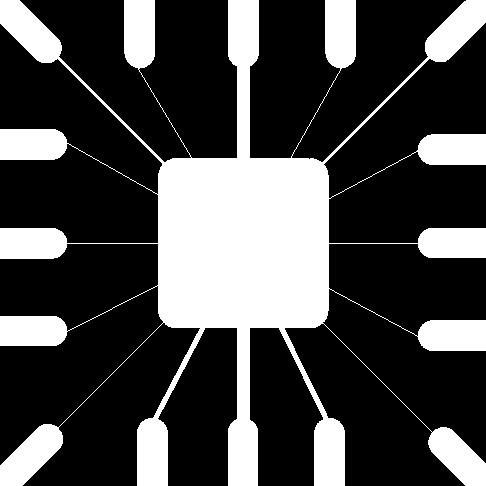

이진화 결과


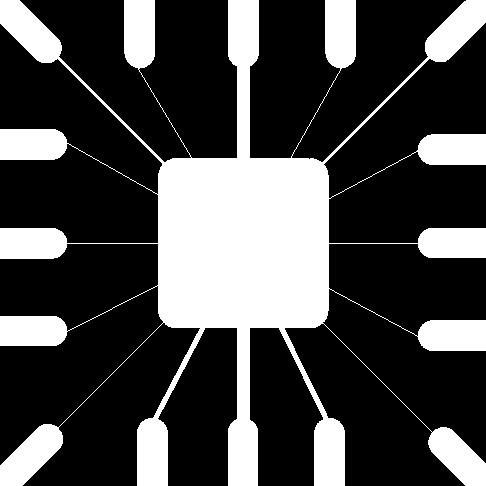

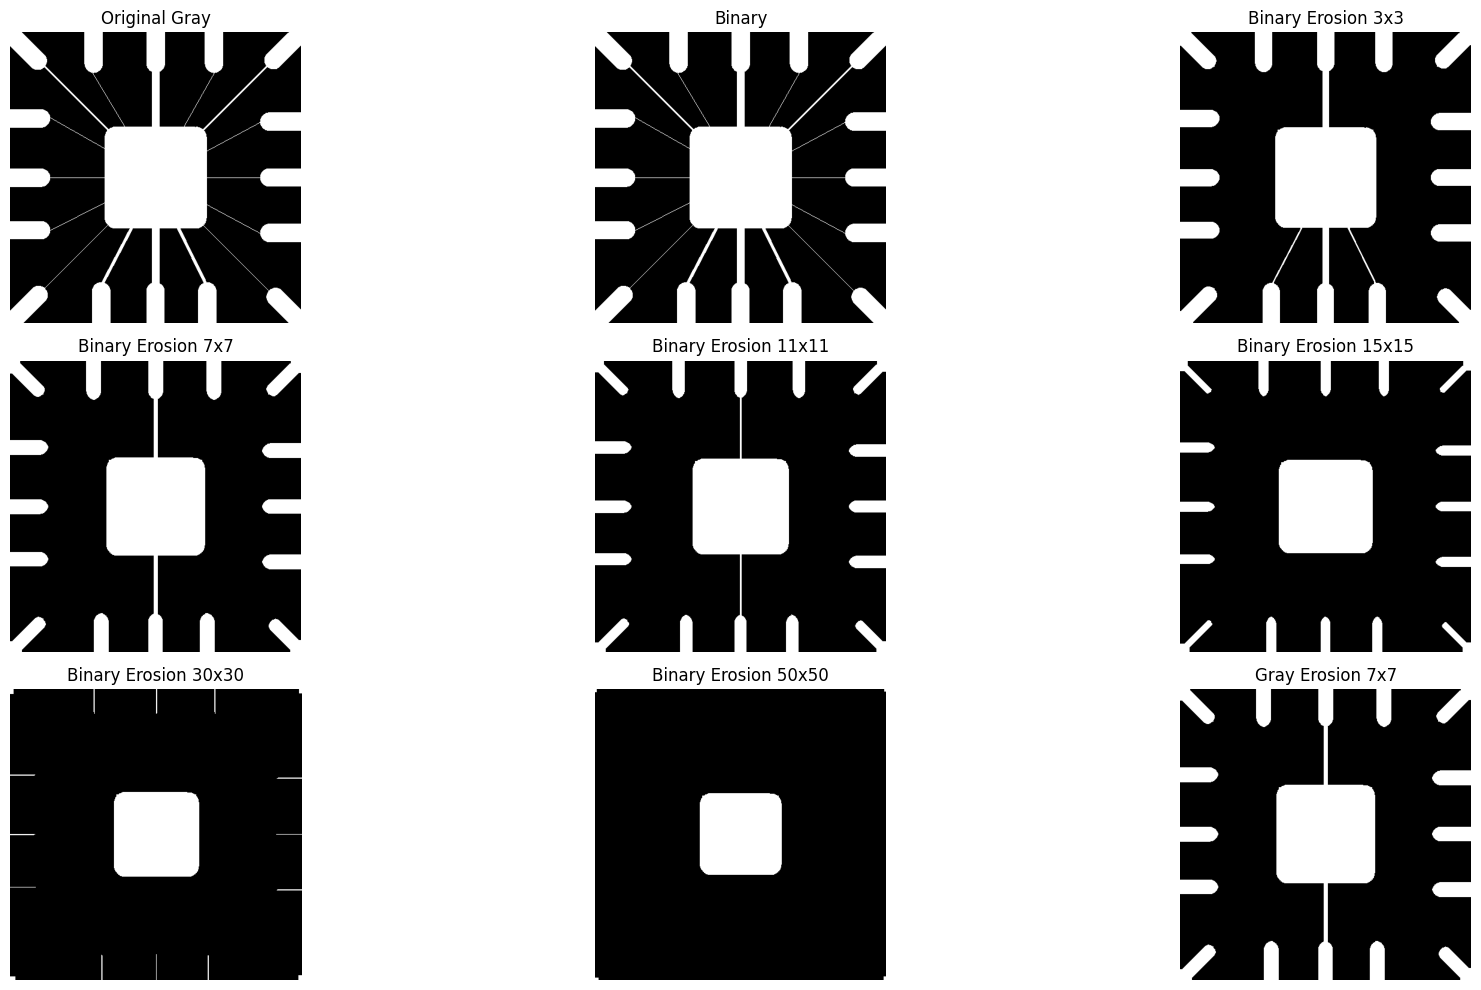

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

img = cv2.imread('/content/Fig0905(a)(wirebond-mask).tif', cv2.IMREAD_GRAYSCALE)

cv2_imshow(img)

# 2) 이진화
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("이진화 결과")
cv2_imshow(binary)

# 3) 구조요소
kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)
kernel15 = np.ones((15, 15), np.uint8)
kernel30 = np.ones((30, 30), np.uint8)
kernel35 = np.ones((35, 35), np.uint8)


# 4) binary erosion
erosion3 = cv2.erode(binary, kernel3, iterations=1)
erosion7 = cv2.erode(binary, kernel7, iterations=1)
erosion11 = cv2.erode(binary, kernel11, iterations=1)
erosion15 = cv2.erode(binary, kernel15, iterations=1)
erosion30 = cv2.erode(binary, kernel30, iterations=1)
erosion35 = cv2.erode(binary, kernel35, iterations=1)


# 5) grayscale erosion
gray_erosion = cv2.erode(img, kernel7, iterations=1)

# 6) 출력
titles = [
    'Original Gray', 'Binary', 'Binary Erosion 3x3',
    'Binary Erosion 7x7', 'Binary Erosion 11x11','Binary Erosion 15x15','Binary Erosion 30x30','Binary Erosion 50x50' ,'Gray Erosion 7x7'
]
images = [img, binary, erosion3, erosion7, erosion11,erosion15,erosion30,erosion35, gray_erosion]

plt.figure(figsize=(20, 10)) # Adjusted figure size for better display
for i in range(len(images)):
    plt.subplot(3, 3, i + 1) # Changed subplot grid to 3 rows, 3 columns to accommodate 9 images
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

#침식연산의 파라미터를 조절하며 선분을 제거함 15x15에서 얇은 선분이 제거되었으며
#35X35에서 두꺼운 선분까제 제거가 되었음